## 6. Exploratory Data Analysis <a name='eda'></a>

In [1]:
# ── EDA Setup: load cleaned CSVs produced by Press_start_main.ipynb ──────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline

# ── Constants (must match Press_start_main.ipynb) ─────────────────────────────
BASE_DIR  = '/content/press_start'
CLEAN_DIR = os.path.join(BASE_DIR, 'clean')
PLOT_DIR  = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET_COL   = 'Estimated_Owners'
FEATURE_COLS = ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio',
                'DLC_Count', 'Release_Month']
COLORS       = ['#4C72B0', '#DD8452', '#55A868']

# ── Load the three cleaned CSVs ───────────────────────────────────────────────
clean_files = {
    'Dataset 1 (nikdavis)':     os.path.join(CLEAN_DIR, 'dataset1_clean.csv'),
    'Dataset 2 (fronkongames)': os.path.join(CLEAN_DIR, 'dataset2_clean.csv'),
    'Dataset 3 (trolukovich)':  os.path.join(CLEAN_DIR, 'dataset3_clean.csv'),
}

datasets = {}
for name, path in clean_files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"[!] '{path}' not found.\n"
            f"    Run all cells in Press_start_main.ipynb first to generate the cleaned CSVs."
        )
    df = pd.read_csv(path)
    datasets[name] = df
    print(f"{name}  |  shape: {df.shape}")

print("\nCleaned datasets loaded ✓")
print(f"TARGET_COL   : {TARGET_COL}")
print(f"FEATURE_COLS : {FEATURE_COLS}")


Dataset 1 (nikdavis)  |  shape: (27075, 23)
Dataset 2 (fronkongames)  |  shape: (19676, 44)
Dataset 3 (trolukovich)  |  shape: (32520, 26)

Cleaned datasets loaded ✓
TARGET_COL   : Estimated_Owners
FEATURE_COLS : ['Price', 'Genre', 'Is_Holiday', 'Positive_Ratio', 'DLC_Count', 'Release_Month']


### 6.1 Summary Statistics

In [2]:
for name, df in datasets.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    display(df[FEATURE_COLS + [TARGET_COL]].describe().round(3))


Dataset 1 (nikdavis)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,27075.000,27075.000,27075.0,27075.000,27075.0,0.0,27075.000
mean,6.078,594.435,0.0,0.714,0.0,NaN,9.968
std,7.875,372.713,0.0,0.234,0.0,NaN,1.301
min,0.000,0.000,0.0,0.000,0.0,NaN,9.210
25%,1.690,310.000,0.0,0.583,0.0,NaN,9.210
50%,3.990,542.000,0.0,0.760,0.0,NaN,9.210
75%,7.190,815.000,0.0,0.894,0.0,NaN,10.463
max,421.990,1551.000,0.0,1.000,0.0,NaN,14.221



Dataset 2 (fronkongames)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,19676.000,19676.000,19676.0,19676.000,19676.0,19676.0,19676.000
mean,35.006,642.938,0.0,0.798,0.0,6.0,2.065
std,32.227,391.770,0.0,0.154,0.0,0.0,1.715
min,0.000,0.000,0.0,0.000,0.0,6.0,0.693
25%,0.000,328.000,0.0,0.718,0.0,6.0,0.693
50%,35.000,644.000,0.0,0.839,0.0,6.0,1.386
75%,65.000,955.000,0.0,0.917,0.0,6.0,2.773
max,100.000,1289.000,0.0,1.000,0.0,6.0,8.219



Dataset 3 (trolukovich)


,Price,Genre,Is_Holiday,Positive_Ratio,DLC_Count,Release_Month,Estimated_Owners
count,32520.000,32520.000,32520.0,32520.0,32520.0,0.0,32520.000
mean,57.948,529.422,0.0,0.5,0.0,NaN,9.672
std,5424.975,318.990,0.0,0.0,0.0,NaN,0.409
min,0.100,0.000,0.0,0.5,0.0,NaN,8.517
25%,2.990,268.000,0.0,0.5,0.0,NaN,9.210
50%,5.990,540.000,0.0,0.5,0.0,NaN,9.904
75%,12.990,828.000,0.0,0.5,0.0,NaN,9.904
max,730640.000,1013.000,0.0,0.5,0.0,NaN,9.904


### 6.2 Target Distribution — Raw vs log₁⁺

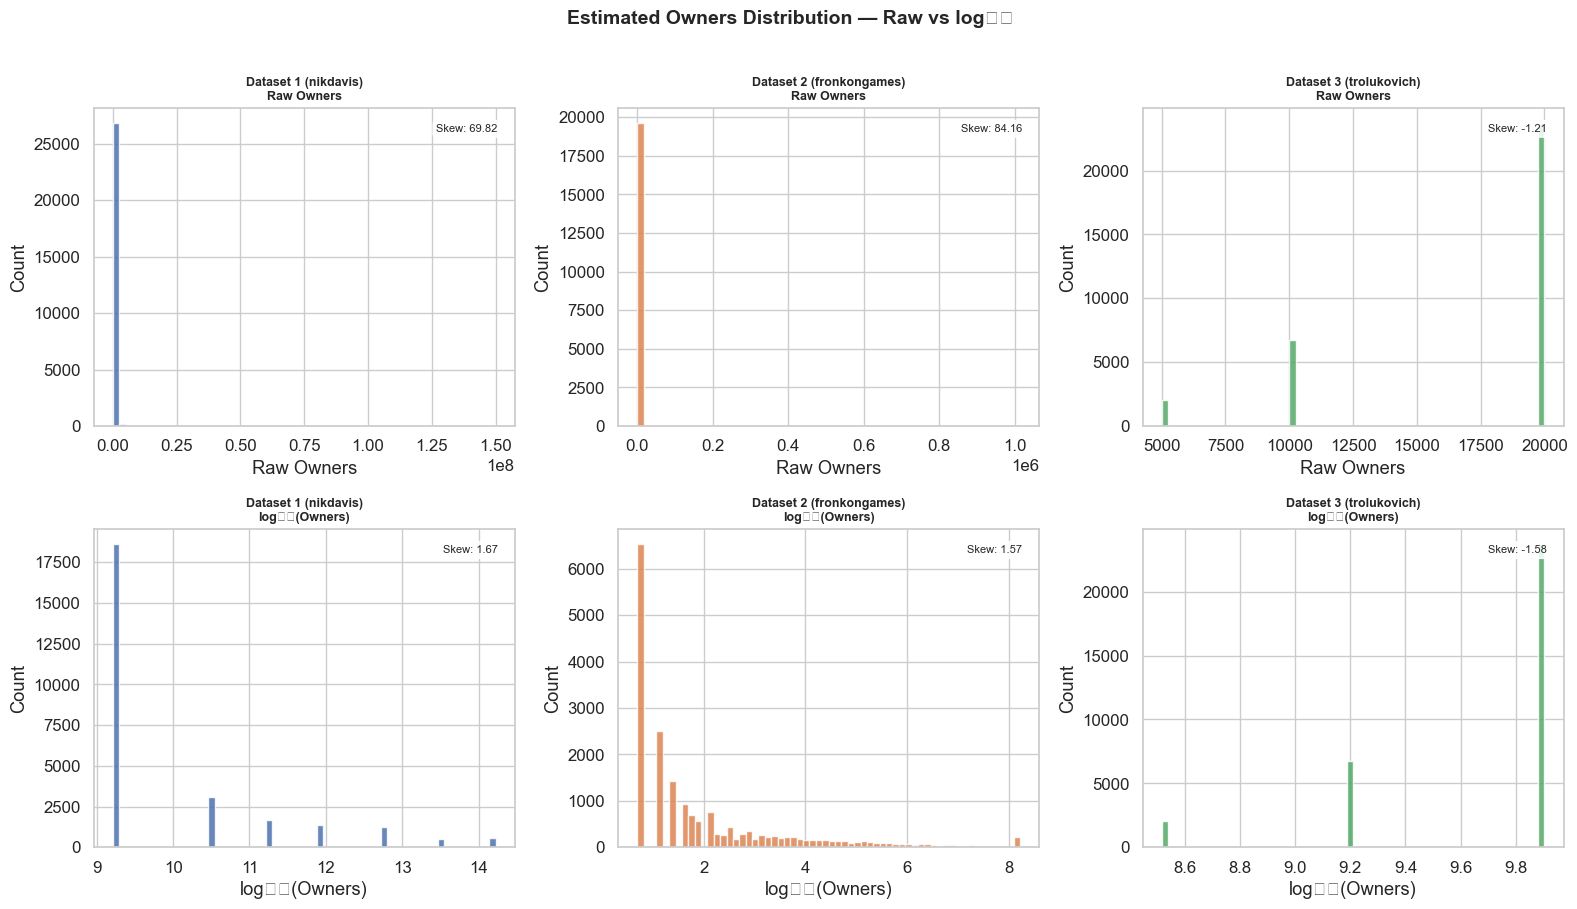

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Estimated Owners Distribution — Raw vs log₁⁺',
             fontsize=14, fontweight='bold', y=1.01)

for i, (name, df) in enumerate(datasets.items()):
    raw = df[TARGET_COL + '_raw']
    log = df[TARGET_COL]

    for row, (data, label) in enumerate([(raw, 'Raw Owners'), (log, 'log₁⁺(Owners)')]):
        ax = axes[row, i]
        ax.hist(data, bins=60, color=COLORS[i], edgecolor='white', alpha=0.85)
        ax.set_title(f'{name}\n{label}', fontweight='bold', fontsize=9)
        ax.set_xlabel(label)
        ax.set_ylabel('Count')
        ax.text(0.96, 0.95, f'Skew: {data.skew():.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Price vs Estimated Owners — the key relationship

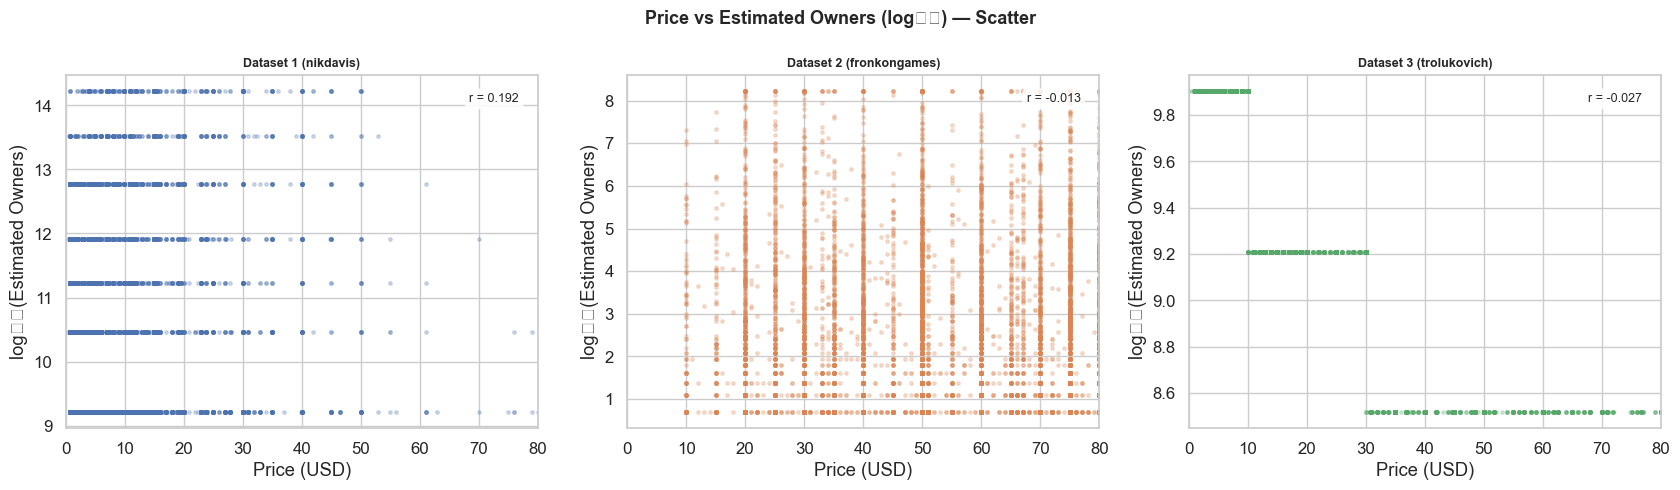

Note: Negative r confirms that higher prices are associated with fewer owners.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Price vs Estimated Owners (log₁⁺) — Scatter',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    # Only show paid games (price > 0) for clarity
    paid = df[df['Price'] > 0].copy()
    ax.scatter(paid['Price'], paid[TARGET_COL],
               alpha=0.25, s=6, color=color)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('log₁⁺(Estimated Owners)')
    ax.set_xlim(0, 80)

    # Correlation annotation
    corr = paid['Price'].corr(paid[TARGET_COL])
    ax.text(0.96, 0.95, f'r = {corr:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'price_vs_owners.png'), dpi=150)
plt.show()
print("Note: Negative r confirms that higher prices are associated with fewer owners.")

### 6.4 Median Owners by Price Tier

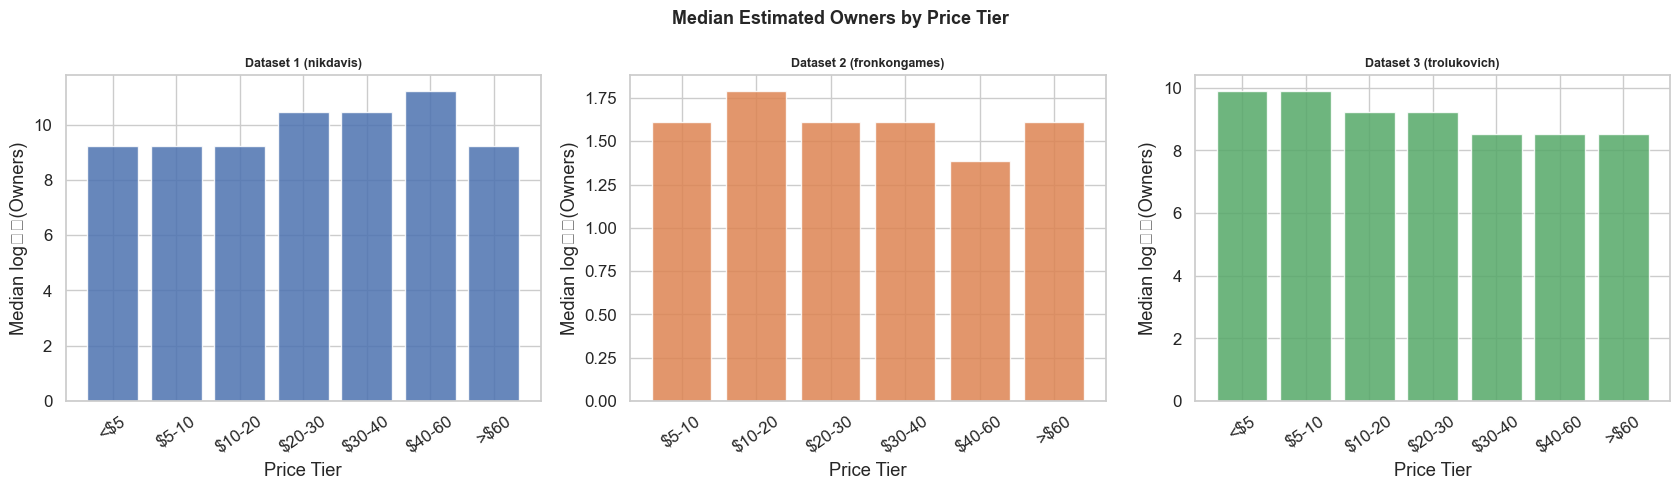

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Estimated Owners by Price Tier',
             fontsize=13, fontweight='bold')

bins   = [0, 0.01, 5, 10, 20, 30, 40, 60, 200]
labels = ['Free', '<$5', '$5-10', '$10-20', '$20-30', '$30-40', '$40-60', '>$60']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    df_temp = df.copy()
    df_temp['Price_Tier'] = pd.cut(df_temp['Price'], bins=bins, labels=labels)
    grp = (df_temp.groupby('Price_Tier', observed=True)[TARGET_COL]
                  .median()
                  .reset_index())
    ax.bar(grp['Price_Tier'].astype(str), grp[TARGET_COL],
           color=color, edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Price Tier')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_price_tier.png'), dpi=150)
plt.show()

### 6.5 Seasonality — Holiday vs Non-Holiday Releases

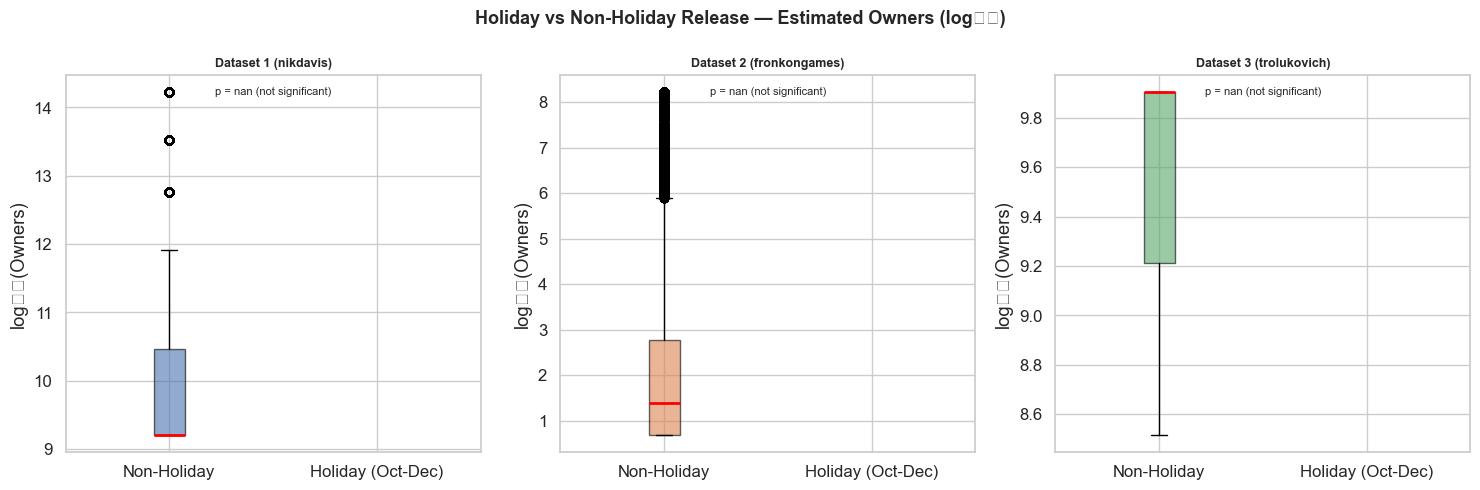

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Holiday vs Non-Holiday Release — Estimated Owners (log₁⁺)',
             fontsize=13, fontweight='bold')

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    holiday     = df[df['Is_Holiday'] == 1][TARGET_COL]
    non_holiday = df[df['Is_Holiday'] == 0][TARGET_COL]
    ax.boxplot([non_holiday, holiday],
               labels=['Non-Holiday', 'Holiday (Oct-Dec)'],
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_ylabel('log₁⁺(Owners)')

    # T-test
    from scipy import stats
    t, p = stats.ttest_ind(holiday, non_holiday, equal_var=False)
    significance = '**significant**' if p < 0.05 else 'not significant'
    ax.text(0.5, 0.97, f'p = {p:.3f} ({significance})',
            transform=ax.transAxes, ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'seasonality.png'), dpi=150)
plt.show()

### 6.6 Correlation Heatmaps

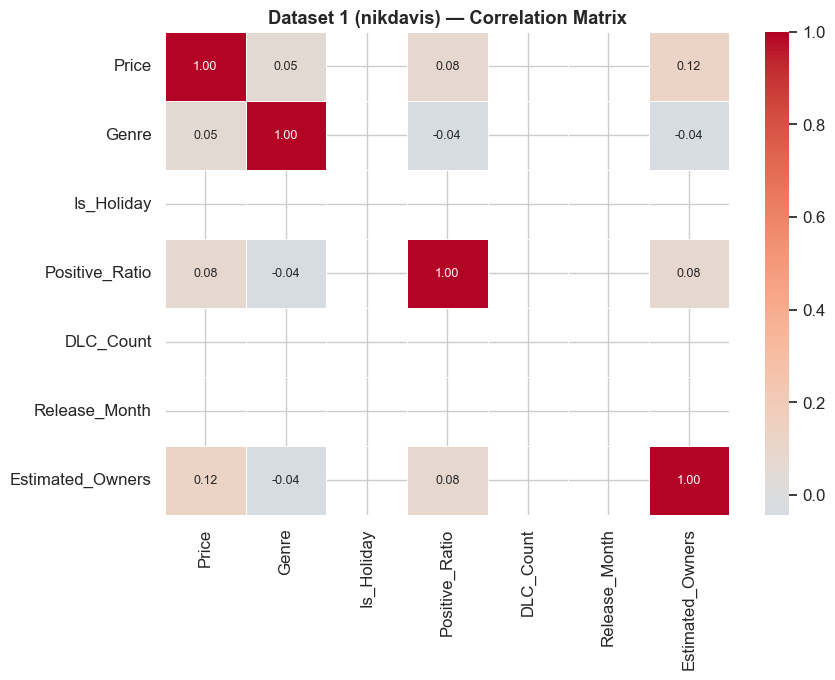

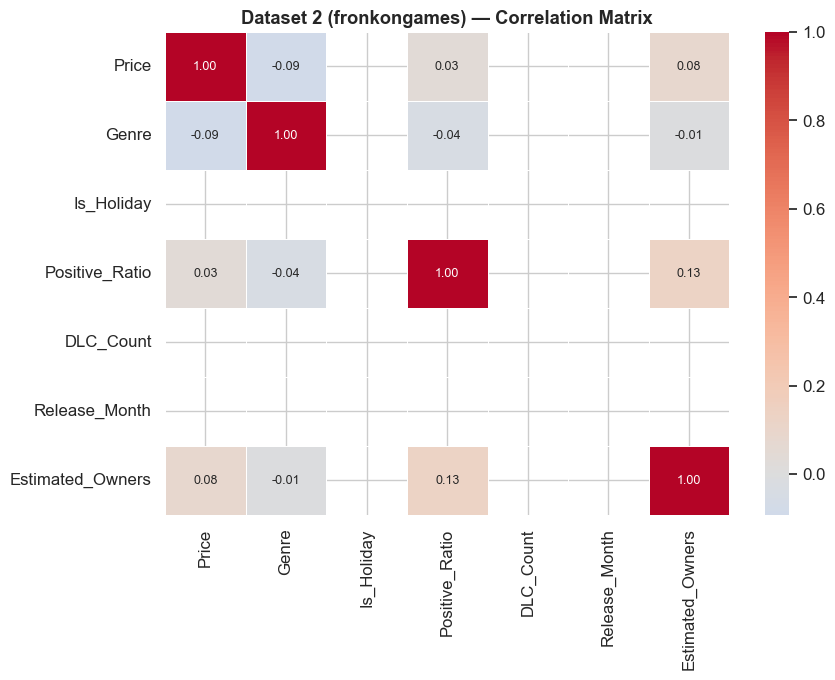

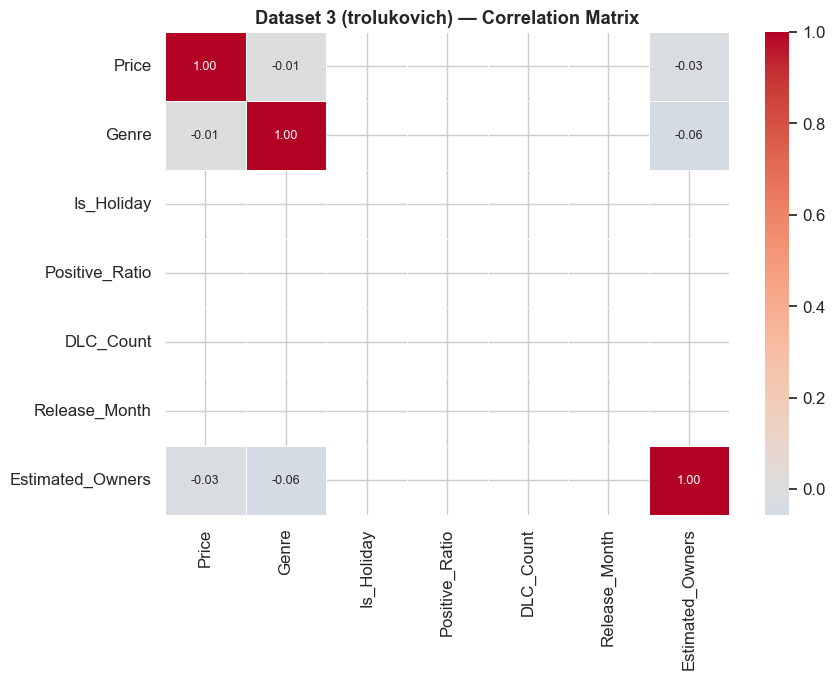

In [7]:
for name, df in datasets.items():
    cols = [c for c in FEATURE_COLS + [TARGET_COL]
            if c in df.columns and '_raw' not in c]
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.4, annot_kws={'size': 9})
    ax.set_title(f'{name} — Correlation Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR,
                f'correlation_{name[:10].replace(" ","_")}.png'), dpi=150)
    plt.show()

### 6.7 Sales Over Time by Release Month

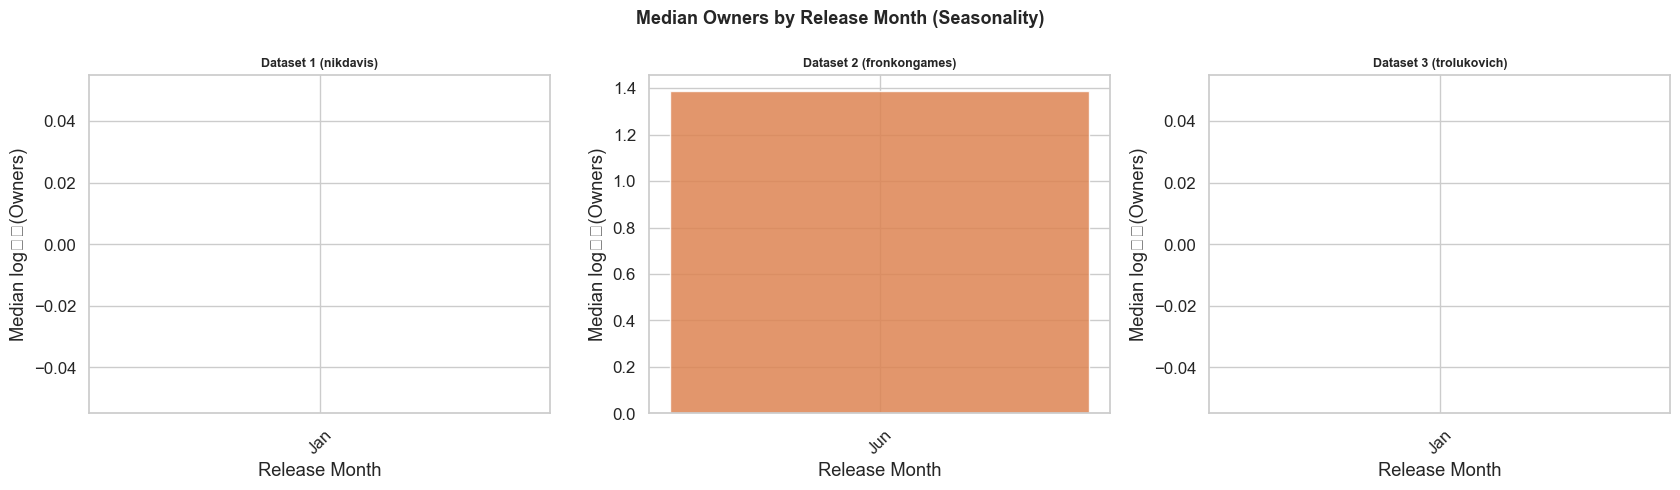

Red-outlined bars = Oct, Nov, Dec (holiday window)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Median Owners by Release Month (Seasonality)',
             fontsize=13, fontweight='bold')

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (name, df), color in zip(axes, datasets.items(), COLORS):
    if 'Release_Month' not in df.columns: continue
    grp = (df.groupby('Release_Month')[TARGET_COL]
             .median()
             .reindex(range(1, 13)))
    ax.bar(month_names, grp.values, color=color, edgecolor='white', alpha=0.85)
    # Shade holiday months
    for x in [9, 10, 11]:
        ax.get_children()[x].set_edgecolor('red')
        ax.get_children()[x].set_linewidth(2)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Release Month')
    ax.set_ylabel('Median log₁⁺(Owners)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'owners_by_month.png'), dpi=150)
plt.show()
print("Red-outlined bars = Oct, Nov, Dec (holiday window)")